# Librería 

In [2]:
import numpy as np # Importa NumPy para trabajar con arreglos y matrices (base del laberinto)
import matplotlib.pyplot as plt # Importa matplotlib para graficar y visualizar el entorno
from matplotlib.colors import ListedColormap # Permite crear mapas de colores personalizados (útil para pintar el laberinto)
import matplotlib.patches as mpatches # Importa utilidades para crear leyendas personalizadas
np.set_printoptions(suppress=True) # Quita la notación científica

Definición del laberinto como una matriz 10x10
- $0$ = camino libre (el agente puede pasar)
- $1$ = obstáculo o pared (el agente no puede pasar)

# Teoría

**Regla de actualización**

$$ Q(s,a) \leftarrow Q(s,a) + \alpha \left[ r + \gamma \max_{a'} Q(s',a') - Q(s,a) \right] $$

**Número de episodios**
$$ N_{\text{episodes}} $$

Es el número de veces que el agente interactúa con el entorno desde el estado inicial hasta terminar.


**Tasa de aprendizaje**

$$\alpha \in (0,1)$$

Controla cuánto se actualiza el valor Q:

$$Q_{\text{nuevo}} = Q_{\text{actual}} + \alpha \cdot (\text{error})$$

**Factor de descuento**

$$ \gamma \in (0,1)$$

Define la importancia de las recompensas futuras:

$$r + \gamma \max_{a'} Q(s', a')$$

**Política $\epsilon$-greedy**

$$
\pi(a|s) =
\begin{cases}
\text{acción aleatoria} & \text{con probabilidad } \epsilon \\
\arg\max_a Q(s,a) & \text{con probabilidad } 1 - \epsilon
\end{cases}
$$


**Espacio de acciones**

$$
A = \{ \text{izquierda}, \text{derecha}, \text{arriba}, \text{abajo} \}
$$

$$
a \in A
$$

$$
s \rightarrow s'
$$

**Objetivo del agente**

$$\mathbb{E} \left[ \sum_{t=0}^{\infty} \gamma^t r_t \right]$$

El agente busca maximizar la recompensa acumulada a lo largo del tiempo.

**Función de recompensa**

La recompensa es una función que asigna un valor inmediato al agente tras ejecutar una acción:

$$
R: S \times A \rightarrow \mathbb{R}
$$

o de forma más general:

$$
R(s,a,s')
$$

donde:

- $s$ = estado actual  
- $a$ = acción tomada  
- $s'$ = siguiente estado  

**Retorno acumulado (Return)**

El objetivo del agente no es maximizar una recompensa inmediata, sino la suma acumulada de recompensas:

$$
G_t = \sum_{k=0}^{\infty} \gamma^k r_{t+k}
$$

donde:

- $G_t$ = retorno desde el tiempo $t$  
- $\gamma$ = factor de descuento  
- $r_{t+k}$ = recompensa futura  


**Intuición clave**

La recompensa define el comportamiento:

- Recompensas mal diseñadas ⇒ aprendizaje incorrecto  
- Recompensas bien diseñadas ⇒ comportamiento óptimo 

**Recompensas mal balanceadas**

$$|R_{\text{goal}}| \ll |R_{\text{step}}|$$

→ El agente evita moverse  

**Sin penalización por paso**

$$R_{\text{step}} = 0$$

→ El agente puede quedarse en bucles 

**Castigos muy altos**

$$R_{\text{fire}} \ll 0$$

→ El agente evita explorar  

In [18]:
maze = np.array([
    [0, 1, 1, 0, 1, 1, 0, 1, 0, 1],  # Fila 0
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],  # Fila 1
    [1, 0, 1, 0, 1, 0, 1, 1, 0, 1],  # Fila 2
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],  # Fila 3
    [1, 0, 1, 1, 0, 1, 1, 0, 1, 1],  # Fila 4
    [0, 0, 1, 0, 0, 0, 0, 0, 0, 0],  # Fila 5
    [1, 0, 0, 0, 1, 0, 1, 0, 1, 0],  # Fila 6
    [1, 0, 1, 0, 1, 0, 0, 0, 1, 1],  # Fila 7
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 1],  # Fila 8
    [0, 1, 1, 0, 1, 0, 1, 1, 0, 0]   # Fila 9
])

In [19]:
maze

array([[0, 1, 1, 0, 1, 1, 0, 1, 0, 1],
       [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
       [1, 0, 1, 0, 1, 0, 1, 1, 0, 1],
       [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
       [1, 0, 1, 1, 0, 1, 1, 0, 1, 1],
       [0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
       [1, 0, 0, 0, 1, 0, 1, 0, 1, 0],
       [1, 0, 1, 0, 1, 0, 0, 0, 1, 1],
       [0, 0, 0, 0, 0, 0, 1, 0, 0, 1],
       [0, 1, 1, 0, 1, 0, 1, 1, 0, 0]])

Definición del punto de inicio del agente
- (fila, columna) -> esquina superior izquierda

In [21]:
start = (0, 0)

Definición del objetivo (meta) del agente
- (fila, columna) -> esquina inferior derecha

In [23]:
goal = (9, 9)

Visualización del laberinto

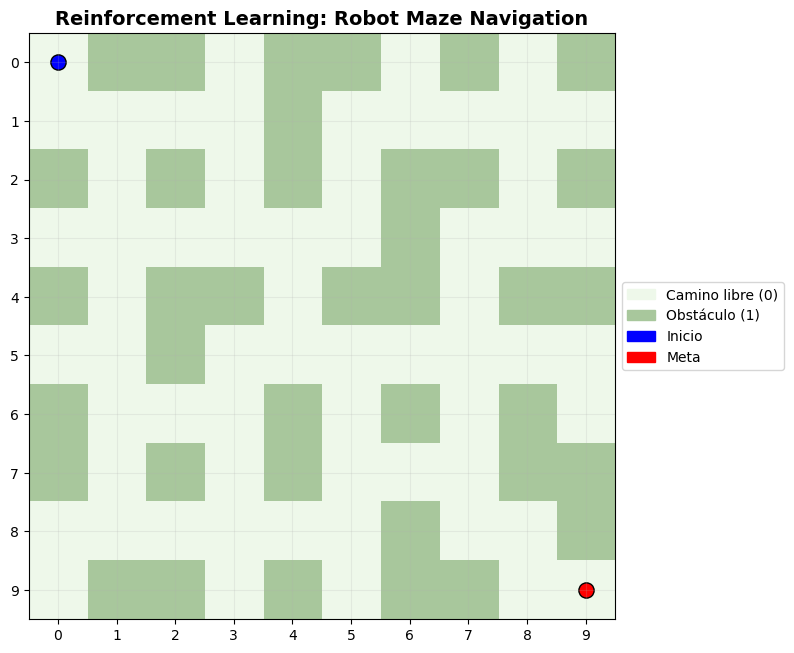

In [25]:
# ==============================
# COLORES DEL LABERINTO
# ==============================

# Definimos un mapa de colores:
# camino = verde muy claro - #eef8ea
# pared = verde más oscuro - #a8c79c
cmap = ListedColormap(['#eef8ea', '#a8c79c'])

# ==============================
# CREACIÓN DE LA FIGURA
# ==============================

plt.figure(figsize=(8, 8))

plt.imshow(maze, cmap=cmap) # Muestra el laberinto como imagen

plt.title('Reinforcement Learning: Robot Maze Navigation', fontsize=14, fontweight='bold') # Título del gráfico

# Invertimos el eje Y para que (0,0) esté arriba como en matrices
# plt.gca().invert_yaxis()

# Mostrar coordenadas en los ejes
plt.xticks(range(maze.shape[1]))
plt.yticks(range(maze.shape[0]))

plt.grid(True, alpha=0.2) # Agregar una cuadrícula ligera

# ==============================
# MARCAR INICIO Y META
# ==============================

# IMPORTANTE:
# En scatter: (x, y) = (columna, fila)

plt.scatter(start[1], start[0],
            color='blue', s=120, edgecolors='black',
            label='Inicio')

plt.scatter(goal[1], goal[0],
            color='red', s=120, edgecolors='black',
            label='Meta')

# ==============================
# LEYENDA PERSONALIZADA
# ==============================

# Parches para explicar colores del mapa
camino = mpatches.Patch(color='#eef8ea', label='Camino libre (0)')
pared = mpatches.Patch(color='#a8c79c', label='Obstáculo (1)')

# Elementos de inicio y meta (para que también aparezcan en la leyenda)
inicio = mpatches.Patch(color='blue', label='Inicio')
meta = mpatches.Patch(color='red', label='Meta')

# Mostrar leyenda completa
plt.legend(handles=[camino, pared, inicio, meta],
           loc='center left',
           bbox_to_anchor=(1, 0.5),
           frameon=True)

# ==============================
# AJUSTES FINALES
# ==============================

plt.tight_layout()
plt.show()

# Parámetros de entrenamiento

Número total de episodios de entrenamiento
- Cuántas veces el agente intentará resolver el laberinto

In [28]:
num_episodes = 5000
num_episodes

5000

Tasa de aprendizaje (learning rate)
- Qué tanto se actualizan los valores de la Q-table en cada iteración


In [30]:
alpha = 0.1  
alpha

0.1

Factor de descuento (discount factor)
- Qué tanto importan las recompensas futuras vs las inmediatas

In [32]:
gamma = 0.9  
gamma

0.9

Probabilidad de exploración (epsilon-greedy)
- $0.5$ = $50$% del tiempo explora (movimientos aleatorios)
- $50$% del tiempo explota (usa lo aprendido)

In [34]:
epsilon = 0.5
epsilon

0.5

## Sistema de recompensas

Castigo fuerte por caer en un obstáculo o estado no deseado

In [37]:
reward_fire = -10  
reward_fire

-10

Recompensa alta por llegar a la meta

In [39]:
reward_goal = 50  
reward_goal 

50

Penalización por cada paso.
- Esto incentiva encontrar caminos más cortos.

In [41]:
reward_step = -1  
reward_step

-1

## Espacio de acciones

Lista de posibles movimientos del agente:
- (fila, columna)

In [44]:
actions = [
    (0, -1),   # Izquierda
    (0, 1),    # Derecha
    (-1, 0),   # Arriba
    (1, 0)     # Abajo
]
actions

[(0, -1), (0, 1), (-1, 0), (1, 0)]

| Acción    | Movimiento | Explicación                  |
|----------|-----------|------------------------------|
| (0, -1)  | Izquierda | misma fila, columna -1       |
| (0, 1)   | Derecha   | misma fila, columna +1       |
| (-1, 0)  | Arriba    | fila -1 (subes)              |
| (1, 0)   | Abajo     | fila +1 (bajas)              |

Tamaño de la matriz 

In [47]:
maze.shape 

(10, 10)

Tamaño de las acciones

In [49]:
(len(actions),) 

(4,)

Se usa normalmente para crear la Q-table <code> np.zeros </code> crea un arreglo lleno de ceros con esa forma

In [51]:
Q = np.zeros(maze.shape + (len(actions),))
Q[0]

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

Resultado:

$q\_table$ tendrá dimensiones:

(filas, columnas, acciones): (10, 10, 4)

**Interpretación en Q-learning:**

q_table $[i, j, a]$ representa:
- El valor (Q-value) de tomar la acción 'a' estando en el estado (i, j) del laberinto

Es decir: Para cada posición del laberinto, guardamos un valor por cada acción posible

In [53]:
Q.shape

(10, 10, 4)

# Funciones

In [55]:
maze.shape[0]  #máximo valor en la fila

10

In [56]:
maze.shape[1] # Máximo valor en la columna

10

In [57]:
def is_valid(pos):  # Política de validación de estados
    r, c = pos # pos es una tupla (r, c) → r = fila, c = columna
    
    # Verifica si la fila está fuera del laberinto (arriba o abajo)
    if r < 0 or r >= maze.shape[0]:
        return False  # Estado inválido

    # Verifica si la columna está fuera del laberinto (izquierda o derecha)
    if c < 0 or c >= maze.shape[1]:
        return False  # Estado inválido

    # Verifica si la posición es una pared (valor 1 en el laberinto)
    if maze[r, c] == 1:
        return False  # No se puede pasar por paredes

    # Si pasa todas las validaciones, es un estado válido
    return True

In [58]:
np.random.randint(len(actions))

0

Política $\epsilon $-greedy: balancea exploración y explotación

In [60]:
def choose_action(state): 
    # Genera un número aleatorio entre 0 y 1 Se usa para decidir si explorar o explotar
    if np.random.random() < epsilon:
        # ==============================
        # EXPLORACIÓN (con probabilidad ε)
        # ==============================
        
        # Selecciona una acción aleatoria
        # len(actions) = número total de acciones posibles
        # np.random.randint(...) devuelve un índice aleatorio
        # Ejemplo: 0=arriba, 1=abajo, 2=izquierda, 3=derecha
        return np.random.randint(len(actions))
    
    else:
        
        # ==============================
        # EXPLOTACIÓN (con probabilidad 1 - ε)
        # ==============================
        
        # Q[state] obtiene todos los valores Q del estado actual
        # Ejemplo: [Q(arriba), Q(abajo), Q(izq), Q(der)]
        
        # np.argmax(...) devuelve el índice de la acción con mayor valor Q
        # Es decir, la mejor acción aprendida hasta ahora
        return np.argmax(Q[state])

Recorrido óptimo del laberinto

In [62]:
def get_optimal_path(Q, start, goal, actions, maze, max_steps=200):
    
    path = [start]  # Lista que guarda el camino recorrido (inicia en el punto inicial)
    state = start   # Estado actual del agente
    visited = set()  # Conjunto para evitar ciclos (estados ya visitados)

    # Se limita el número de pasos para evitar loops infinitos
    for _ in range(max_steps):
        
        # Si llega a la meta, termina
        if state == goal:
            break

        # Marca el estado actual como visitado
        visited.add(state)

        best_action = None  # Mejor acción encontrada
        best_value = -float('inf')  # Valor inicial muy bajo

        # ==============================
        # EVALUAR TODAS LAS ACCIONES
        # ==============================
        for idx, move in enumerate(actions):
            
            # Calcula el siguiente estado posible
            next_state = (state[0] + move[0], state[1] + move[1])

            # ==============================
            # VALIDACIÓN DEL MOVIMIENTO
            # ==============================
            if (0 <= next_state[0] < maze.shape[0] and   # Dentro de filas
                0 <= next_state[1] < maze.shape[1] and   # Dentro de columnas
                maze[next_state] == 0 and                # No es pared
                next_state not in visited):              # No repetir estados

                # ==============================
                # SELECCIÓN DE LA MEJOR ACCIÓN
                # ==============================
                
                # Compara el valor Q de esta acción
                if Q[state][idx] > best_value:
                    best_value = Q[state][idx]  # Guarda el mejor valor Q
                    best_action = idx           # Guarda el índice de la mejor acción

        # Si no hay acciones válidas, se detiene
        if best_action is None:
            break

        # ==============================
        # EJECUTAR LA MEJOR ACCIÓN
        # ==============================
        
        move = actions[best_action]  # Obtiene el movimiento óptimo
        
        # Actualiza el estado
        state = (state[0] + move[0], state[1] + move[1])
        
        # Agrega el nuevo estado al camino
        path.append(state)

    # Devuelve el camino óptimo encontrado
    return path

Visualización del laberinto y camino

In [64]:
# Imprimimos (graficamos) el resultado
def plot_maze_with_path(path):
    
    # Definimos un mapa de colores:
    # 0 → camino libre (verde muy claro)
    # 1 → pared (verde más oscuro)
    cmap = ListedColormap(['#eef8ea', '#a8c79c'])

    # Creamos la figura con tamaño 8x8
    plt.figure(figsize=(8, 8))
    
    # Mostramos el laberinto como imagen
    plt.imshow(maze, cmap=cmap)

    # ==============================
    # DIBUJAR START Y GOAL
    # ==============================

    # Punto inicial (robot)
    # OJO: matplotlib usa (x, y) → (columna, fila)
    plt.scatter(start[1], start[0], 
                marker='o', color='#81c784', edgecolors='black',
                s=200, label='Start (Robot)', zorder=5)

    # Meta (diamante)
    plt.scatter(goal[1], goal[0], 
                marker='*', color='#388e3c', edgecolors='black',
                s=300, label='Goal (Diamond)', zorder=5)

    # ==============================
    # DIBUJAR EL CAMINO APRENDIDO
    # ==============================

    # Separa filas y columnas del path
    # path = [(r1,c1), (r2,c2), ...]
    rows, cols = zip(*path)

    # Dibuja la línea del recorrido
    plt.plot(cols, rows, 
             color='#60b37a', linewidth=4,
             label='Learned Path', zorder=4)

    # ==============================
    # CONFIGURACIÓN DE LA GRÁFICA
    # ==============================

    # Título del gráfico
    plt.title('Reinforcement Learning: Robot Maze Navigation')

    # Invierte el eje Y (opcional, para que coincida con matrices)
    # plt.gca().invert_yaxis()

    # Muestra las divisiones según el tamaño del maze
    plt.xticks(range(maze.shape[1]))  # columnas
    plt.yticks(range(maze.shape[0]))  # filas

    # Agrega una cuadrícula ligera
    plt.grid(True, alpha=0.2)

    # Muestra la leyenda
    plt.legend()

    # Ajusta el layout para que no se encimen elementos
    plt.tight_layout()

    # Muestra la gráfica final
    plt.show()

# Entrenamiento

Ecuacion Q Learning

- Alfa es el learning rate
- Gamma factor de descuento

$$Q ( S ,A )←Q ( S ,A )+α ( R+γ Q ( S′,A′)−Q ( S ,A ))$$

In [67]:
rewards_all_episodes = []  # Lista para guardar la recompensa total obtenida en cada episodio

# ==============================
# ENTRENAMIENTO
# ==============================
for episode in range(num_episodes):  # Recorre todos los episodios de entrenamiento
    
    state = start  # Estado inicial del agente (posición inicial en el laberinto)
    total_rewards = 0  # Acumulador de recompensas en este episodio
    done = False  # Indica si el episodio ha terminado

    # ==============================
    # LOOP DEL EPISODIO
    # ==============================
    while not done:
        
        # Selecciona una acción usando política ε-greedy
        action_index = choose_action(state)
        
        # Obtiene el vector de movimiento asociado a la acción
        action = actions[action_index]

        # Calcula el siguiente estado (nueva posición)
        next_state = (state[0] + action[0], state[1] + action[1])

        # ==============================
        # DEFINICIÓN DE RECOMPENSAS
        # ==============================
        
        if not is_valid(next_state):  
            # Si se sale del mapa o choca con pared
            reward = reward_fire  # castigo
            done = True  # termina el episodio

        elif next_state == goal:  
            # Si llega a la meta
            reward = reward_goal  # recompensa positiva
            done = True  # termina el episodio

        else:
            # Movimiento válido pero no es meta
            reward = reward_step  # pequeña penalización por cada paso

        # ==============================
        # ACTUALIZACIÓN Q-LEARNING
        # ==============================
        
        old_value = Q[state][action_index]  
        # Valor Q actual para (estado, acción)

        next_max = np.max(Q[next_state]) if is_valid(next_state) else 0  
        # Mejor valor Q del siguiente estado (máxima acción posible)
        # Si el estado no es válido, se toma 0

        # Fórmula de Q-learning:
        # Q(s,a) ← Q(s,a) + α [ r + γ max Q(s',a') - Q(s,a) ]
        Q[state][action_index] = old_value + alpha * \
            (reward + gamma * next_max - old_value)

        # Actualiza el estado actual
        state = next_state
        
        # Acumula recompensa del episodio
        total_rewards += reward

    # ==============================
    # DECAIMIENTO DE EXPLORACIÓN
    # ==============================
    
    global epsilon  # usa la variable global epsilon
    
    # Reduce epsilon gradualmente (menos exploración con el tiempo)
    epsilon = max(0.01, epsilon * 0.995)

    # Guarda la recompensa total del episodio
    rewards_all_episodes.append(total_rewards)

In [68]:
print(Q) #Lo aprendido

[[[-9.86697205 -9.35389181 -9.92144833  0.00630902]
  [ 0.          0.          0.          0.        ]
  [ 0.          0.          0.          0.        ]
  [-6.12579511 -6.12579511 -6.12579511 -6.00906209]
  [ 0.          0.          0.          0.        ]
  [ 0.          0.          0.          0.        ]
  [-3.439      -4.0951     -3.439      -3.34478035]
  [ 0.          0.          0.          0.        ]
  [-2.71       -2.71       -2.71       -2.73319081]
  [ 0.          0.          0.          0.        ]]

 [[-9.41850263  1.11812113 -2.8833136  -9.7972444 ]
  [-2.33823327 -6.35939609 -9.7972444   2.35346793]
  [-6.3914973  -4.720578   -6.5132156  -8.49905365]
  [-6.04093881 -7.17570464 -6.04288407 -0.60711198]
  [ 0.          0.          0.          0.        ]
  [-4.0951     -3.73100869 -4.0951     -3.75805314]
  [-3.37629327 -3.39775609 -3.39655804 -3.439     ]
  [-3.07567998 -3.06108813 -3.439      -3.439     ]
  [-2.74578906 -2.76300775 -2.75663049 -2.78675845]
  [-2.7414

Obtener camino óptimo

In [70]:
optimal_path = get_optimal_path(Q, start, goal, actions, maze)
optimal_path

[(0, 0),
 (1, 0),
 (1, 1),
 (2, 1),
 (3, 1),
 (3, 2),
 (3, 3),
 (3, 4),
 (4, 4),
 (5, 4),
 (5, 5),
 (5, 6),
 (5, 7),
 (6, 7),
 (7, 7),
 (8, 7),
 (8, 8),
 (9, 8),
 (9, 9)]

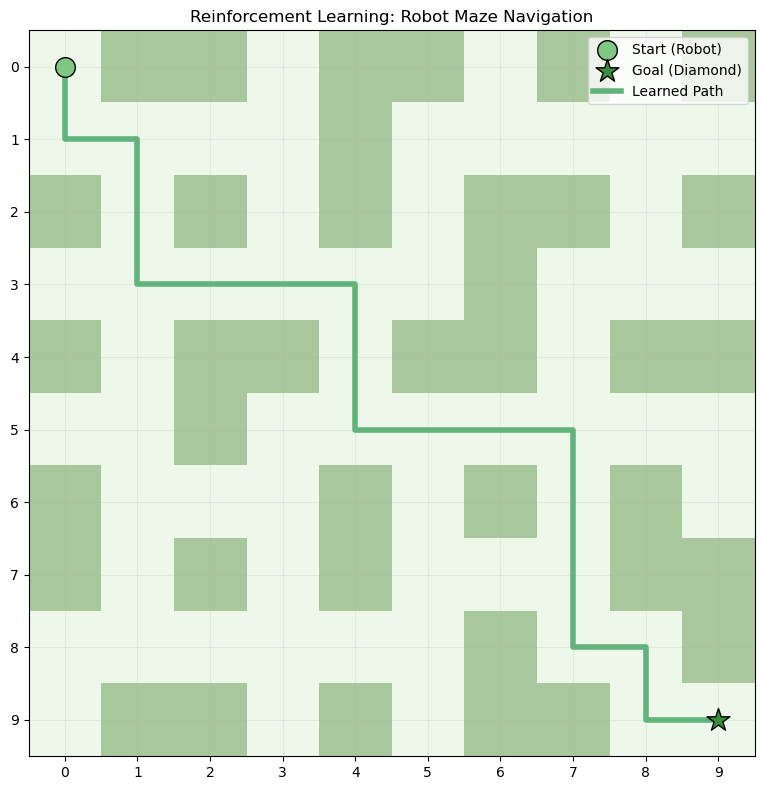

In [71]:
plot_maze_with_path(optimal_path)